In [1]:
import pandas as pd
import numpy as np
from dython.nominal import associations
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# 'Malgun Gothic' 폰트를 기본으로 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_parquet('1.회원정보_train.parquet')
df1 = pd.read_parquet('5.잔액정보_train.parquet')

In [3]:
df = df['Segment']

df2 = pd.concat([df, df1], axis = 1)

df2.head()

,Segment,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,...,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,D,201807,TRAIN_000000,998,962,22971,0,0,0,1084,...,15988,2440,0,0,0,572,0,17008,0,0
1,E,201807,TRAIN_000001,2565,2390,0,0,0,0,4090,...,7045,2677,0,2830,0,2736,0,0,0,0
2,C,201807,TRAIN_000002,5312,5113,21531,6795,0,0,5006,...,66549,9118,0,8870,0,4429,0,43351,0,0
3,D,201807,TRAIN_000003,730,5025,26284,0,0,0,487,...,30139,884,0,0,0,5097,0,30697,0,0
4,E,201807,TRAIN_000004,0,0,0,0,0,0,0,...,28,21,0,0,0,0,0,0,0,0


In [4]:
na_counts = df1.isna().sum()
na_cols = na_counts[na_counts >0]
print(na_cols)

연체일자_B0M    2394336
dtype: int64


In [5]:
df2 = df2.drop('연체일자_B0M', axis=1)

In [7]:
# LabelEncoder 하기

le = LabelEncoder()

df2['Segment'] = le.fit_transform(df2['Segment'])
df2['ID'] = le.fit_transform(df2['ID'])

In [12]:
# 피어슨 상관계수 구하기
correlations = df2.corr()["Segment"].sort_values(ascending=False)

In [13]:
significant_corr = correlations[correlations.abs() >= 0.5]
print(significant_corr)

Segment    1.0
Name: Segment, dtype: float64


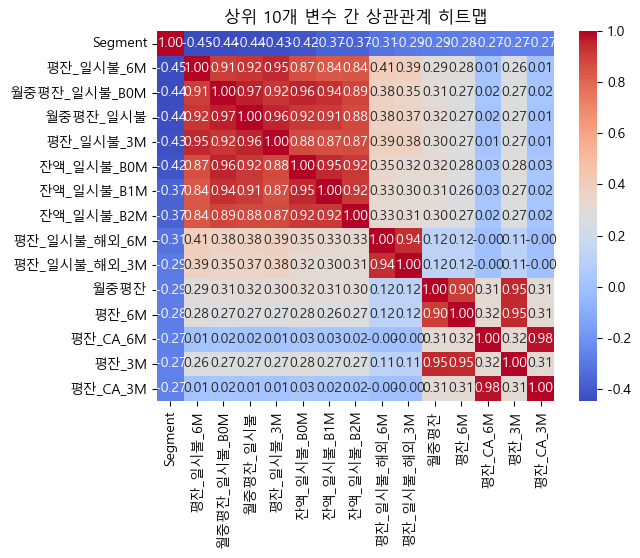

In [14]:
# Segment와 관련 있는 상위 10개 변수만 선택
top_features = correlations.abs().sort_values(ascending=False).head(15).index
sns.heatmap(df2[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상위 10개 변수 간 상관관계 히트맵")
plt.show()